# CMR Boundary-Signal Simulation — Targeted Comparison

This notebook runs three conditions through a 32-item list with boundaries at positions 9, 17, and 25 (four 8-item segments). Each condition specifies a (non-boundary, boundary) drift pair:

| Condition | Non-boundary drift | Boundary drift | Interpretation |
|---|---|---|---|
| **Baseline** | 0.6 | 0.8 | Healthy encoding with intact boundary boost |
| **H1 — Boundary impairment** | 0.6 | 0.6 | Boundary boost abolished; tonic drift intact |
| **H2 — Global reduction** | 0.4 | 0.6 | All drifts lowered; boundary still above baseline |

H1 and H2 share the same boundary drift (0.6) but differ in their non-boundary drift. The question is whether these two routes to impaired recall leave distinguishable signatures in boundary-local transitions, SPC, lag-CRP, and overall accuracy.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings, importlib
warnings.filterwarnings("ignore")

import src.config as cfg
import src.simulation as sim
import src.metrics as met

importlib.reload(cfg)
importlib.reload(sim)
importlib.reload(met)

N    = cfg.N
bps  = cfg.BOUNDARY_POSITIONS
N_SIMS = cfg.N_SIMS
SEED   = cfg.SEED

positions = np.arange(1, N + 1)

print(f"N = {N}, boundaries at {bps}, {N_SIMS} sims per condition")

N = 32, boundaries at [9, 17, 25], 1000 sims per condition


## Define conditions and drift schedules

Each condition is a `(non-boundary, boundary)` drift pair. The schedules are built with `build_global_schedule`, which assigns one drift to non-boundary positions and another to boundary positions.

In [2]:
CONDITIONS = {
    "Baseline (0.6 / 0.8)": (0.6, 0.8),
    "H1: boundary impaired (0.6 / 0.6)": (0.6, 0.6),
    "H2: global reduction (0.4 / 0.6)": (0.4, 0.6),
}

schedules = {}
for label, (b_non, b_bdy) in CONDITIONS.items():
    schedules[label] = sim.build_global_schedule(b_non, b_bdy)
    print(sim.describe_schedule(schedules[label]))
    print()

N = 32, boundaries at [9, 17, 25]
non-boundary drift: 0.600 (range 0.600–0.600)
boundary drift:     0.800 (range 0.800–0.800)

N = 32, boundaries at [9, 17, 25]
non-boundary drift: 0.600 (range 0.600–0.600)
boundary drift:     0.600 (range 0.600–0.600)

N = 32, boundaries at [9, 17, 25]
non-boundary drift: 0.400 (range 0.400–0.400)
boundary drift:     0.600 (range 0.600–0.600)



### Visualize drift schedules

The step-function plots below show the per-position encoding drift for each condition. Vertical dashed lines mark boundary positions. Small vertical offsets are for visual separation only; true values are unchanged.

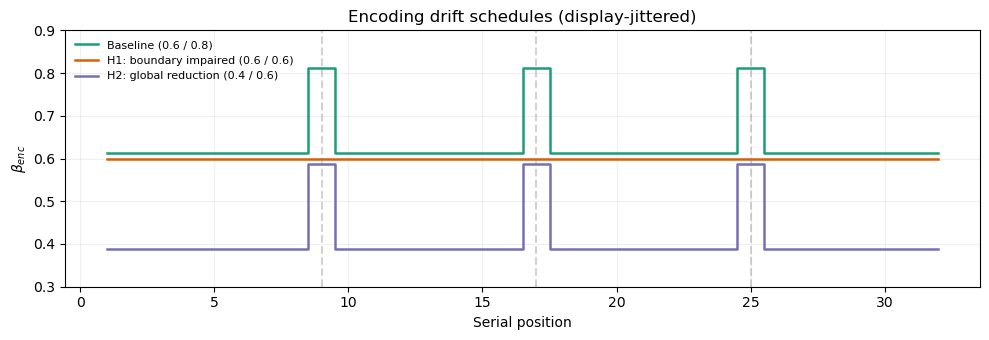

In [16]:
COLORS = {
    "Baseline (0.6 / 0.8)": "#1b9e77",
    "H1: boundary impaired (0.6 / 0.6)": "#d95f02",
    "H2: global reduction (0.4 / 0.6)": "#7570b3",
}

OFFSETS = {
    "Baseline (0.6 / 0.8)":  0.012,
    "H1: boundary impaired (0.6 / 0.6)": 0.0,
    "H2: global reduction (0.4 / 0.6)": -0.012,
}

fig, ax = plt.subplots(figsize=(10, 3.5))

for label, B in schedules.items():
    B_plot = np.asarray(B) + OFFSETS[label]
    ax.step(
        positions, B_plot, where='mid',
        lw=1.8, label=label, color=COLORS[label]
    )

for j in bps:
    ax.axvline(j, color='grey', ls='--', alpha=0.35)

ax.set(
    xlabel='Serial position',
    ylabel=r'$\beta_{enc}$',
    title='Encoding drift schedules (display-jittered)',
    ylim=(0.3, 0.9)
)
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Run simulations

In [4]:
results = {}
for label, B in schedules.items():
    print(f"  {label} ...", end=" ")
    results[label] = sim.run_batch(B, n_sims=N_SIMS, seed=SEED, label=label)
    acc = met.recall_accuracy(results[label]['recall_sims'], N)
    print(f"done  (accuracy = {acc:.3f})")

  Baseline (0.6 / 0.8) ... done  (accuracy = 0.164)
  H1: boundary impaired (0.6 / 0.6) ... done  (accuracy = 0.164)
  H2: global reduction (0.4 / 0.6) ... done  (accuracy = 0.270)


## Compute metrics

For each condition we compute whole-list metrics (SPC, PFR, lag-CRP, recall accuracy), boundary-local metrics (three lag-1 transitions around each boundary, boundary-local SPC), and train-level recall (Polyn 2009-style proportion recalled from each segment).

> **TrainMean** is the unweighted mean of train-level recall proportions. It matches whole-list accuracy only when all trains have equal length (true here: four 8-item trains).

In [5]:
summaries = {}
for label, res in results.items():
    summaries[label] = met.summarize_condition_metrics(res['recall_sims'], N)

# Boundary transitions + train-level recall table
print(f"{'Condition':<40s}  {'(j-1)→j':>8s}  {'j→(j-1)':>8s}  {'j→(j+1)':>8s}  {'Accuracy':>8s}  {'TrainMean':>9s}")
print('-' * 95)
for label, s in summaries.items():
    print(f"{label:<40s}  "
          f"{s['pre_to_boundary']:8.4f}  "
          f"{s['boundary_backward']:8.4f}  "
          f"{s['boundary_forward']:8.4f}  "
          f"{s['recall_accuracy']:8.4f}  "
          f"{s['mean_train_recall']:9.4f}")

# Per-train breakdown
train_ids, mean_tr_base, se_tr_base = list(summaries.values())[0]['train_recall']
bounds = list(summaries.values())[0]['train_bounds']
header = f"{'Condition':<40s}" + "".join(f"  {'T'+str(t)+' ('+str(b[0])+'-'+str(b[1])+')':>15s}" for t, b in zip(train_ids, bounds))
print("\n" + header)
print('-' * (40 + 17 * len(train_ids)))
for label, s in summaries.items():
    _, mean_tr, se_tr = s['train_recall']
    row = f"{label:<40s}"
    for m, se in zip(mean_tr, se_tr):
        row += f"  {m:7.3f} ±{se:.3f}"
    print(row)

Condition                                  (j-1)→j   j→(j-1)   j→(j+1)  Accuracy  TrainMean
-----------------------------------------------------------------------------------------------
Baseline (0.6 / 0.8)                        0.1212    0.0367    0.1837    0.1643     0.1643
H1: boundary impaired (0.6 / 0.6)           0.1351    0.0714    0.1975    0.1639     0.1639
H2: global reduction (0.4 / 0.6)            0.2026    0.0885    0.1643    0.2698     0.2698

Condition                                        T1 (1-8)        T2 (9-16)       T3 (17-24)       T4 (25-32)
------------------------------------------------------------------------------------------------------------
Baseline (0.6 / 0.8)                        0.004 ±0.001    0.006 ±0.001    0.018 ±0.002    0.629 ±0.005
H1: boundary impaired (0.6 / 0.6)           0.005 ±0.001    0.007 ±0.001    0.026 ±0.002    0.618 ±0.005
H2: global reduction (0.4 / 0.6)            0.004 ±0.001    0.025 ±0.002    0.201 ±0.006    0.850 ±0.004


## Serial position curve

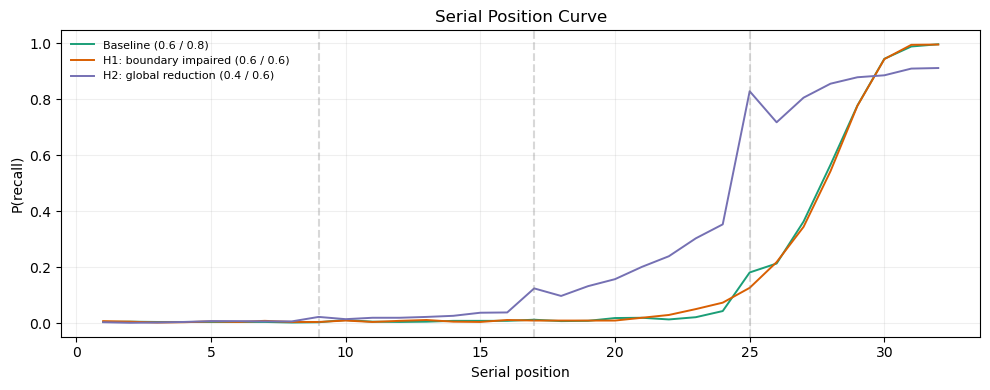

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, s in summaries.items():
    ax.plot(positions, s['whole_spc'], lw=1.4, label=label, color=COLORS[label])
for j in bps:
    ax.axvline(j, color='grey', ls='--', alpha=0.3)
ax.set(xlabel='Serial position', ylabel='P(recall)',
       title='Serial Position Curve')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Probability of first recall

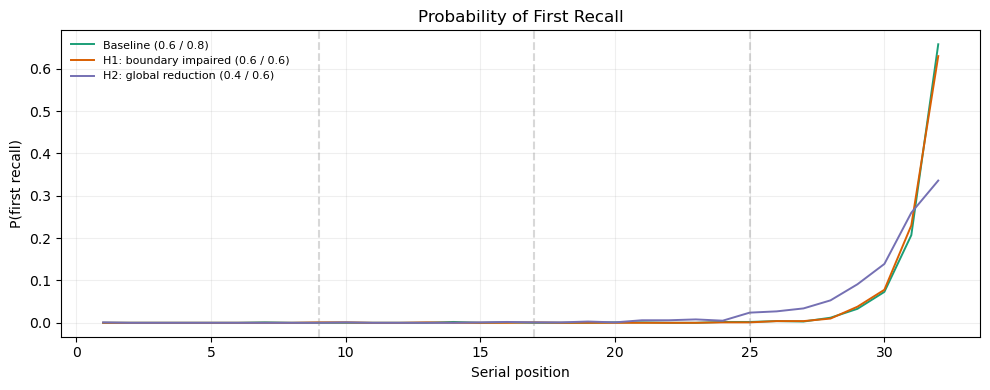

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, s in summaries.items():
    ax.plot(positions, s['whole_pfr'], lw=1.4, label=label, color=COLORS[label])
for j in bps:
    ax.axvline(j, color='grey', ls='--', alpha=0.3)
ax.set(xlabel='Serial position', ylabel='P(first recall)',
       title='Probability of First Recall')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Lag-CRP

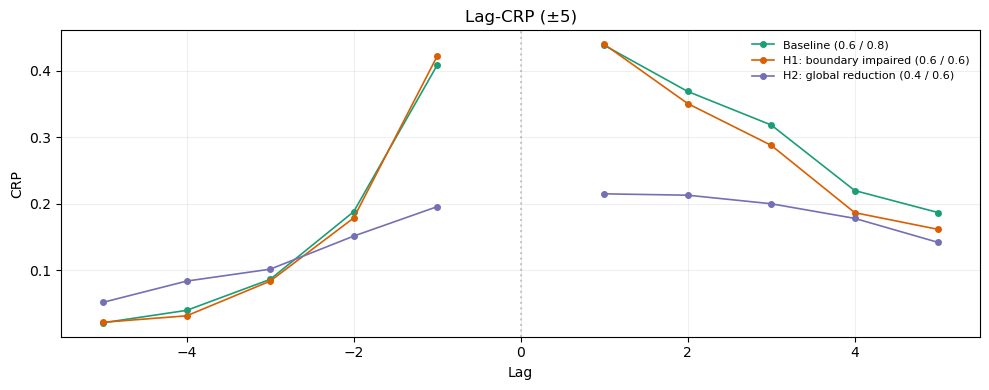

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, s in summaries.items():
    lag_vals, crp = s['whole_lag_crp']

    neg_mask = (lag_vals >= -5) & (lag_vals < 0)
    pos_mask = (lag_vals <= 5) & (lag_vals > 0)

    ax.plot(
        lag_vals[neg_mask], crp[neg_mask],
        marker='o', ms=4, lw=1.2,
        label=label, color=COLORS[label]
    )
    ax.plot(
        lag_vals[pos_mask], crp[pos_mask],
        marker='o', ms=4, lw=1.2,
        color=COLORS[label]
    )

ax.axvline(0, color='grey', ls=':', alpha=0.4)
ax.set(
    xlabel='Lag',
    ylabel='CRP',
    title='Lag-CRP (±5)'
)
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Boundary-local transitions

Three lag-1 transitions defined relative to each boundary position $j$, pooled across all three boundaries:

- **(j−1) → j** — does recall cross *into* the new context?
- **j → (j−1)** — does the boundary item pull recall backward?
- **j → (j+1)** — does the boundary item push recall forward?

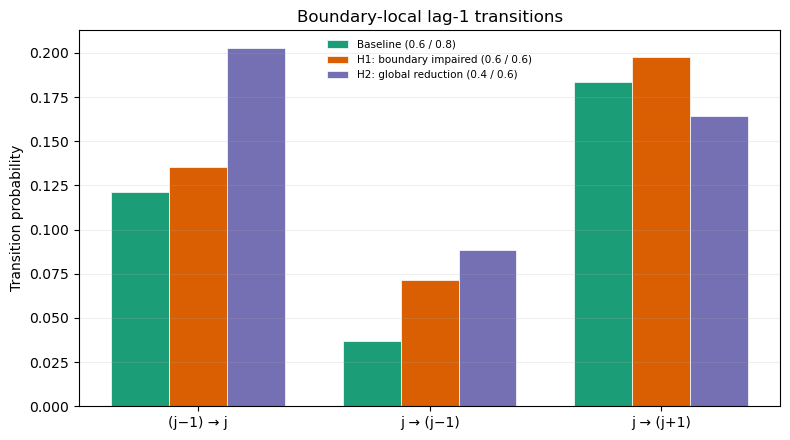

In [9]:
trans_labels = ['(j−1) → j', 'j → (j−1)', 'j → (j+1)']
keys = ['pre_to_boundary', 'boundary_backward', 'boundary_forward']

x = np.arange(len(trans_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (label, s) in enumerate(summaries.items()):
    vals = [s[k] for k in keys]
    ax.bar(x + (i - 1) * width, vals, width, label=label,
           color=COLORS[label], edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(trans_labels)
ax.set_ylabel('Transition probability')
ax.set_title('Boundary-local lag-1 transitions')
ax.legend(fontsize=7.5, frameon=False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## Boundary-local SPC

SPC in a ±4-position window around each boundary, averaged across all three boundary positions. Position 0 on the x-axis is the boundary item itself.

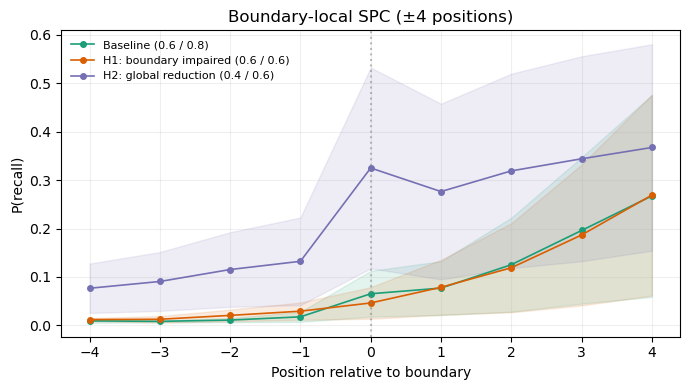

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, s in summaries.items():
    rel, mspc, se = s['boundary_local_spc']
    ax.plot(rel, mspc, marker='o', ms=4, lw=1.2,
            label=label, color=COLORS[label])
    ax.fill_between(rel, mspc - se, mspc + se, alpha=0.12,
                    color=COLORS[label])
ax.axvline(0, color='grey', ls=':', alpha=0.5)
ax.set(xlabel='Position relative to boundary',
       ylabel='P(recall)',
       title='Boundary-local SPC (±4 positions)')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Recall accuracy

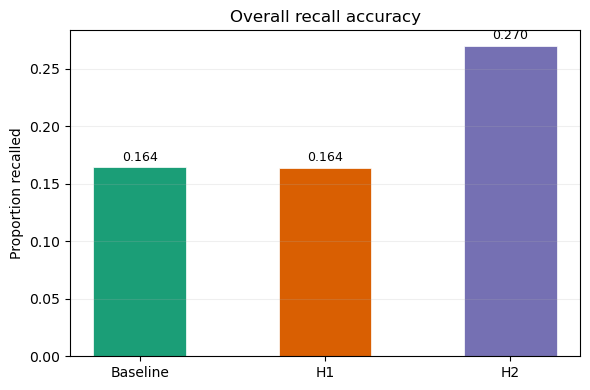

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
labels_short = ['Baseline', 'H1', 'H2']
accs = [summaries[l]['recall_accuracy'] for l in summaries]
bars = ax.bar(labels_short, accs,
              color=[COLORS[l] for l in summaries],
              edgecolor='white', linewidth=0.5, width=0.5)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, a + 0.003,
            f'{a:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Proportion recalled')
ax.set_title('Overall recall accuracy')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## Recall by context

Each train is a segment of the list defined by boundary positions. For the current design: Train 1 = positions 1–8, Train 2 = 9–16, Train 3 = 17–24, Train 4 = 25–32.

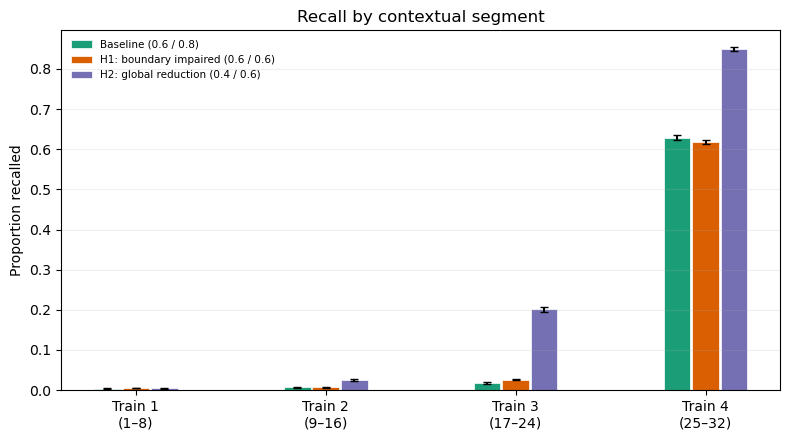

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x_offset = np.linspace(-0.15, 0.15, len(summaries))

for i, (label, s) in enumerate(summaries.items()):
    train_ids, mean_tr, se_tr = s['train_recall']
    x = train_ids + x_offset[i]
    ax.bar(x, mean_tr, width=0.14, yerr=se_tr, capsize=3,
           label=label, color=COLORS[label], edgecolor='white', linewidth=0.5)

ax.set_xticks(train_ids)
bounds = list(summaries.values())[0]['train_bounds']
ax.set_xticklabels([f"Train {t}\n({b[0]}–{b[1]})" for t, b in zip(train_ids, bounds)])
ax.set_ylabel('Proportion recalled')
ax.set_title('Recall by contextual segment')
ax.legend(fontsize=7.5, frameon=False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## Summary panel

A compact 3 × 3 overview combining the key readouts.

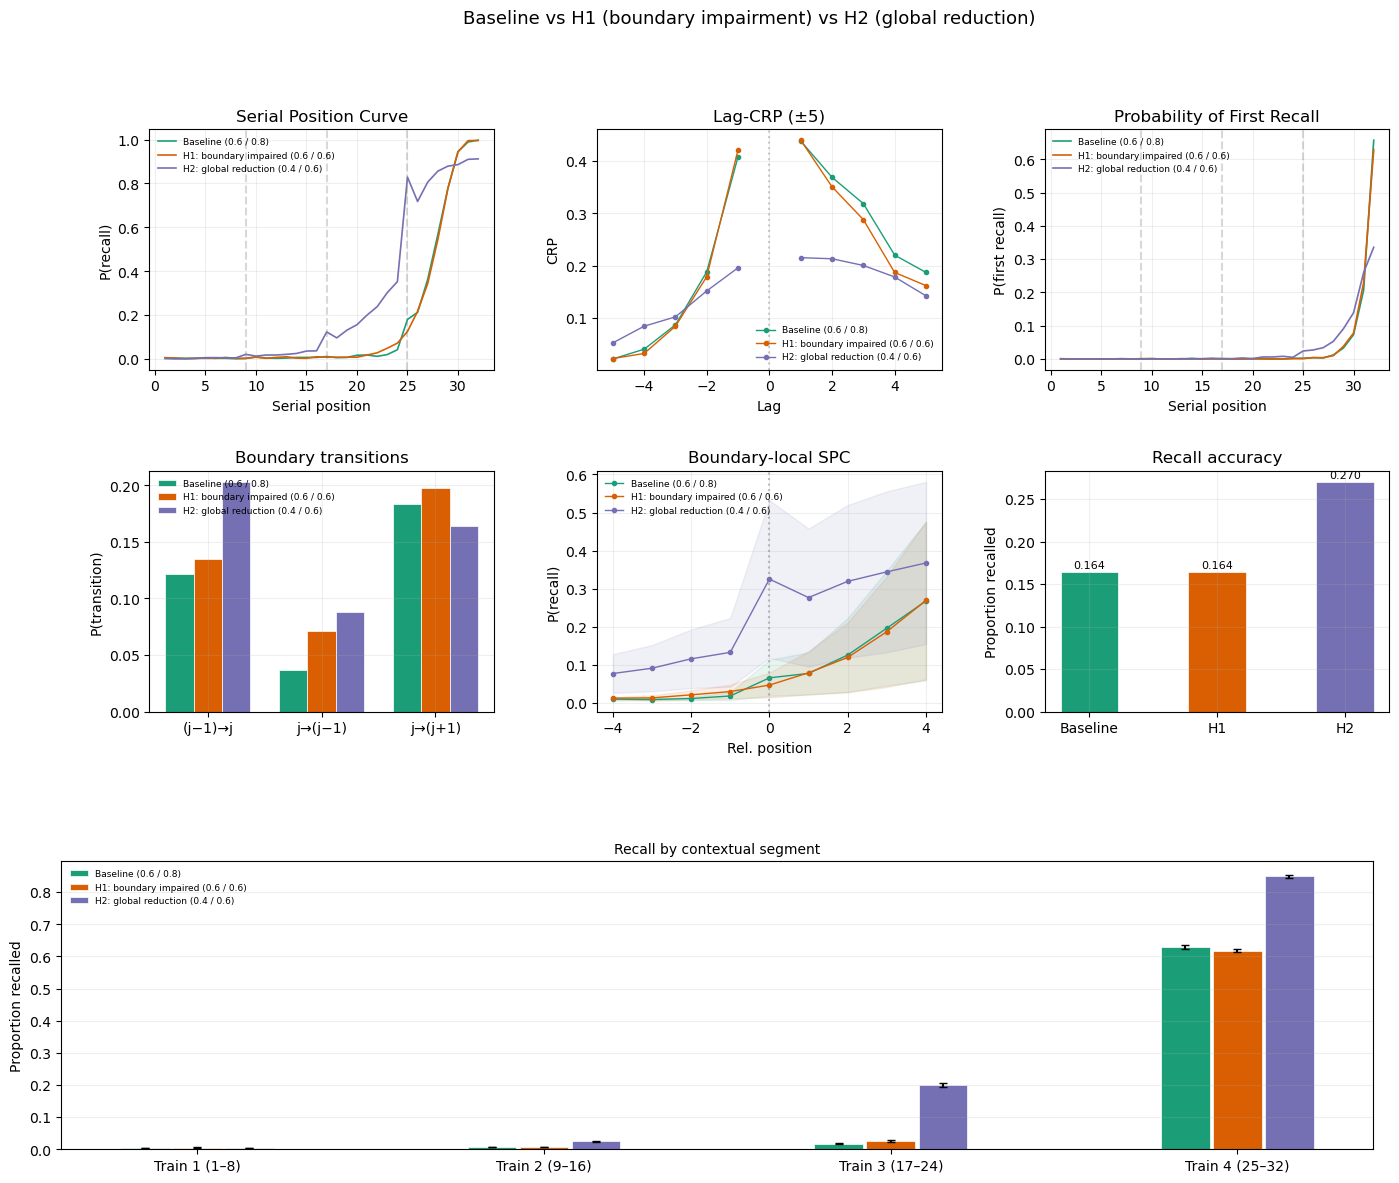

In [19]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12))
fig.subplots_adjust(wspace=0.30, hspace=0.42)

# ── (0, 0) SPC ──
for label, s in summaries.items():
    axs[0, 0].plot(positions, s['whole_spc'], lw=1.2,
                   label=label, color=COLORS[label])
for j in bps:
    axs[0, 0].axvline(j, color='grey', ls='--', alpha=0.3)
axs[0, 0].set(xlabel='Serial position', ylabel='P(recall)',
              title='Serial Position Curve')
axs[0, 0].legend(fontsize=6.5, frameon=False)

# ── (0, 1) Lag-CRP ──
for label, s in summaries.items():
    lv, crp = s['whole_lag_crp']

    neg = (lv >= -5) & (lv < 0)
    pos = (lv > 0) & (lv <= 5)

    axs[0, 1].plot(lv[neg], crp[neg], marker='o', ms=3, lw=1,
                   label=label, color=COLORS[label])
    axs[0, 1].plot(lv[pos], crp[pos], marker='o', ms=3, lw=1,
                   color=COLORS[label])

axs[0, 1].axvline(0, color='grey', ls=':', alpha=0.4)
axs[0, 1].set(xlabel='Lag', ylabel='CRP', title='Lag-CRP (±5)')
axs[0, 1].legend(fontsize=6.5, frameon=False)

# ── (0, 2) PFR ──
for label, s in summaries.items():
    axs[0, 2].plot(positions, s['whole_pfr'], lw=1.2,
                   label=label, color=COLORS[label])
for j in bps:
    axs[0, 2].axvline(j, color='grey', ls='--', alpha=0.3)
axs[0, 2].set(xlabel='Serial position', ylabel='P(first recall)',
              title='Probability of First Recall')
axs[0, 2].legend(fontsize=6.5, frameon=False)

# ── (1, 0) Boundary transitions ──
trans_labels = ['(j−1)→j', 'j→(j−1)', 'j→(j+1)']
keys = ['pre_to_boundary', 'boundary_backward', 'boundary_forward']
x = np.arange(len(trans_labels))
w = 0.25
for i, (label, s) in enumerate(summaries.items()):
    vals = [s[k] for k in keys]
    axs[1, 0].bar(x + (i - 1) * w, vals, w, label=label,
                  color=COLORS[label], edgecolor='white', lw=0.5)
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(trans_labels)
axs[1, 0].set(ylabel='P(transition)', title='Boundary transitions')
axs[1, 0].legend(fontsize=6.5, frameon=False)

# ── (1, 1) Boundary-local SPC ──
for label, s in summaries.items():
    rel, mspc, se = s['boundary_local_spc']
    axs[1, 1].plot(rel, mspc, marker='o', ms=3, lw=1,
                   label=label, color=COLORS[label])
    axs[1, 1].fill_between(rel, mspc - se, mspc + se,
                           alpha=0.1, color=COLORS[label])
axs[1, 1].axvline(0, color='grey', ls=':', alpha=0.5)
axs[1, 1].set(xlabel='Rel. position', ylabel='P(recall)',
              title='Boundary-local SPC')
axs[1, 1].legend(fontsize=6.5, frameon=False)

# ── (1, 2) Recall accuracy ──
short = ['Baseline', 'H1', 'H2']
accs = [summaries[l]['recall_accuracy'] for l in summaries]
bars = axs[1, 2].bar(short, accs,
                     color=[COLORS[l] for l in summaries],
                     edgecolor='white', lw=0.5, width=0.45)
for bar, a in zip(bars, accs):
    axs[1, 2].text(bar.get_x() + bar.get_width() / 2, a + 0.002,
                   f'{a:.3f}', ha='center', va='bottom', fontsize=8)
axs[1, 2].set(ylabel='Proportion recalled', title='Recall accuracy')

# ── (2, 0–2) Train recall ──
# Span across bottom row with a single wide subplot
for col_ax in axs[2, :]:
    col_ax.axis('off')

ax_train = fig.add_axes([0.07, 0.03, 0.82, 0.24])
train_ids_ref, mean_tr_ref, _ = list(summaries.values())[0]['train_recall']
bounds = list(summaries.values())[0]['train_bounds']
x_offset = np.linspace(-0.15, 0.15, len(summaries))

for i, (label, s) in enumerate(summaries.items()):
    t_ids, m_tr, se_tr = s['train_recall']
    xpos = t_ids + x_offset[i]
    ax_train.bar(xpos, m_tr, width=0.14, yerr=se_tr, capsize=3,
                 label=label, color=COLORS[label],
                 edgecolor='white', linewidth=0.5)

ax_train.set_xticks(train_ids_ref)
ax_train.set_xticklabels([f"Train {t} ({b[0]}–{b[1]})"
                           for t, b in zip(train_ids_ref, bounds)])
ax_train.set_ylabel('Proportion recalled')
ax_train.set_title('Recall by contextual segment', fontsize=10)
ax_train.legend(fontsize=6.5, frameon=False)
ax_train.grid(axis='y', alpha=0.2)

for ax in axs[:2].flat:
    ax.grid(alpha=0.2)

fig.suptitle('Baseline vs H1 (boundary impairment) vs H2 (global reduction)',
             fontsize=13, y=0.98)
plt.show()